## Our Framework Evaluation with Wisig Dataset

Dataset: [link](https://cores.ee.ucla.edu/downloads/datasets/wisig/)

In [1]:
%reload_ext autoreload
%autoreload 2

import os
import numpy as np
import matlab
import cfo_utils
import utils
import matplotlib.pyplot as plt
from dataset_api import DatasetAPI
from extractor_api import ExtractorAPI
from evaluation_api import EvaluationAPI
from fingerprinting_api import FingerprintingAPI
from dataset_preparation import ChannelIndSpectrogram
import random
import tensorflow as tf

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

os.environ['TF_DETERMINISTIC_OPS'] = '1'

DATASET_NAME =           DatasetAPI.DATASET_WISIG
RX_NODES =               [DatasetAPI.RX_1]
ROOT_DIRECTORY =         '/home/smazokha2016/Desktop'
MATLAB_SRC_DIRECTORY =   '/home/smazokha2016/Desktop/mobintel-rffi/fingerprinting'
MATLAB_SESSION_ID =      'fp_workflow'
AUG_ON =                 False

DATA_CONFIG = {
    'dataset_name':      DATASET_NAME,
    'frame_count_train': 1000, # 200 for v2, 500 for v4, 500 for wisig
    'frame_count_epoch': 100,
    'samples_count':     400
}

AUG_CONFIG = {
    'multiplier':        5,
    't_rms_bounds':      matlab.double([1, 2]),
    'd_f_bounds':        matlab.double([0, 1]),
    'k_factor_bounds':   matlab.double([0, 1]),
    'awgn':              matlab.double([0, 1]),
}

MODEL_CONFIG = {
    'batch_size':        32,
    'loss_type':         'triplet_loss', 'alpha': 1.0,
    # 'loss_type':         'quadruplet_loss', 'alpha': 1.2,
    'fp_len':            512,
    'row':               100,
    'enable_ind':        False
}

extractor_api = ExtractorAPI()
dataset_api = DatasetAPI(root_dir=ROOT_DIRECTORY, matlab_src_dir=MATLAB_SRC_DIRECTORY, matlab_session_id=MATLAB_SESSION_ID, aug_on=AUG_ON)
fp_api = FingerprintingAPI(rx_ids = RX_NODES, data_config=DATA_CONFIG, aug_config=AUG_CONFIG, model_config=MODEL_CONFIG, root_dir=ROOT_DIRECTORY, matlab_src_dir=MATLAB_SRC_DIRECTORY, matlab_session_id=MATLAB_SESSION_ID, aug_on=AUG_ON)
eval_api = EvaluationAPI(rx_ids = RX_NODES, data_config=DATA_CONFIG, aug_config=AUG_CONFIG, model_config=MODEL_CONFIG, root_dir=ROOT_DIRECTORY, matlab_src_dir=MATLAB_SRC_DIRECTORY, matlab_session_id=MATLAB_SESSION_ID, aug_on=AUG_ON)

2024-11-02 04:14:36.558033: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-11-02 04:14:36.558127: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-11-02 04:14:36.559131: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-02 04:14:36.566717: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-11-02 04:14:37.427065: W tensorflow/compiler/tf2

Devices for training: 33
Devices for testing: 6
Not removing CFO.
Augmenting the dataset: x4, CFO range: [-40, 40], dist: uniform
Not removing CFO.
Augmenting the dataset: x4, CFO range: [-40, 40], dist: uniform
(66000, 400)
Data before filtering: (66000, 400)
Data after filtering: (66000, 400)


2024-11-02 04:15:36.805782: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 79060 MB memory:  -> device: 0, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:03:00.0, compute capability: 8.0
2024-11-02 04:15:36.807340: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 1392 MB memory:  -> device: 1, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:04:00.0, compute capability: 8.0
2024-11-02 04:15:36.808736: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 79060 MB memory:  -> device: 2, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:43:00.0, compute capability: 8.0


Epoch 1/1000


2024-11-02 04:15:40.327975: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8905
2024-11-02 04:15:43.110878: I external/local_xla/xla/service/service.cc:168] XLA service 0x7f67b9de6d70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2024-11-02 04:15:43.110910: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA A100 80GB PCIe, Compute Capability 8.0
2024-11-02 04:15:43.110920: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (1): NVIDIA A100 80GB PCIe, Compute Capability 8.0
2024-11-02 04:15:43.110926: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (2): NVIDIA A100 80GB PCIe, Compute Capability 8.0
2024-11-02 04:15:43.114856: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1730535343.239524 2492255 device_compi

1650/1650 [==============================] - 76s 42ms/step - loss: 0.0404 - val_loss: 0.0087 - lr: 0.0010
Epoch 2/1000
1650/1650 [==============================] - 44s 27ms/step - loss: 0.0044 - val_loss: 0.0019 - lr: 0.0010
Epoch 3/1000
1650/1650 [==============================] - 41s 25ms/step - loss: 0.0018 - val_loss: 0.0013 - lr: 0.0010
Epoch 4/1000
1650/1650 [==============================] - 40s 24ms/step - loss: 0.0011 - val_loss: 9.1816e-04 - lr: 0.0010
Epoch 5/1000
1650/1650 [==============================] - 39s 24ms/step - loss: 8.4725e-04 - val_loss: 7.3893e-04 - lr: 0.0010
Epoch 6/1000
1650/1650 [==============================] - 40s 24ms/step - loss: 5.8004e-04 - val_loss: 3.3395e-04 - lr: 0.0010
Epoch 7/1000
1650/1650 [==============================] - 39s 24ms/step - loss: 3.8228e-04 - val_loss: 2.2030e-04 - lr: 0.0010
Epoch 8/1000
1650/1650 [==============================] - 39s 24ms/step - loss: 3.4583e-04 - val_loss: 1.4832e-04 - lr: 0.0010
Epoch 9/1000
1650/1650 [=

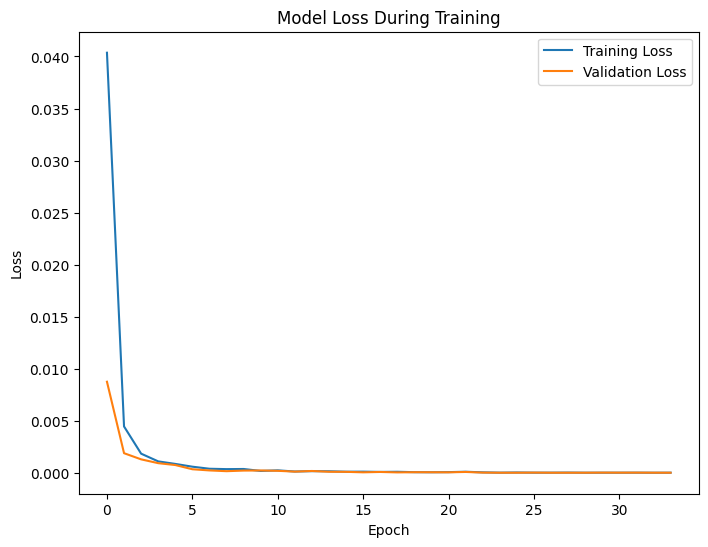

In [2]:
enable_training = True

if enable_training: 
    # models, histories = fp_api.train_models()
    models, histories = fp_api.train_models_wisig(multiday=False, compensate_cfo=False, augment_cfo=True)

    history = histories[RX_NODES[0]]

    plt.figure(figsize=(8, 6))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss During Training')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()
else: 
    models = fp_api.load_models()

model = models[RX_NODES[0]]

Devices for training: 33
Devices for testing: 5
Enrollment devices: [38, 9, 11, 17, 25]
Not removing CFO.
Not augmenting CFO.
Not removing CFO.
Not augmenting CFO.
Removed 137 values.
Not removing CFO.
Not augmenting CFO.
Not removing CFO.
Not augmenting CFO.
Removed 97 values.
Great! Epoch #1 and epoch #2 contain identical sets of device IDs. We can perform closed-set evaluation.


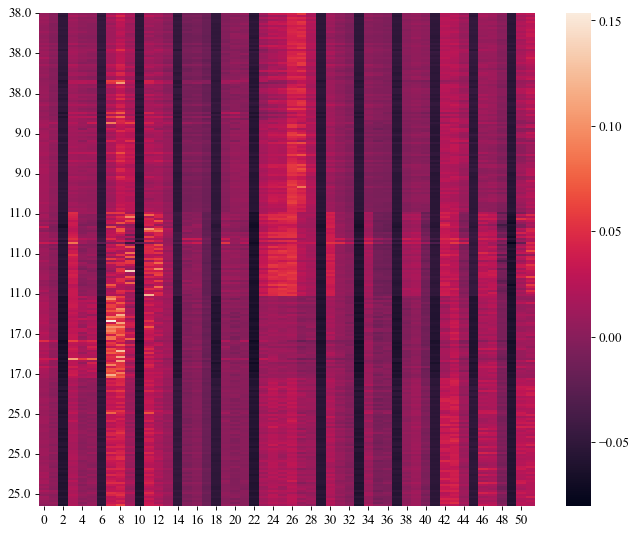

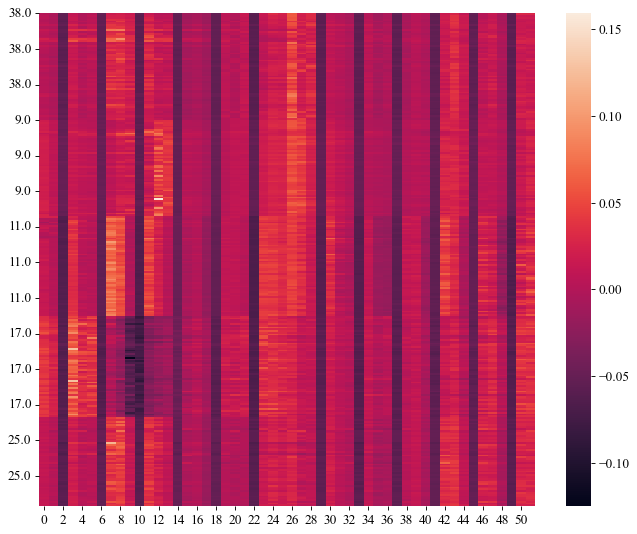

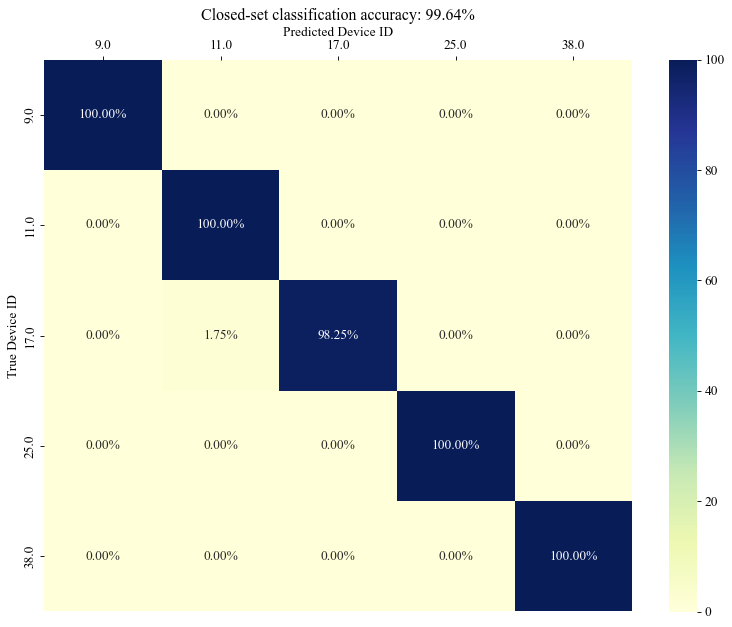

Closed-set classification accuracy: 99.64%


In [13]:
CFO_COMP_ON = False
RSSI_FILTERING_ON = True
CFO_FILTERING_ON = True
CFO_AUG_ON = False

def combine_datasets(datas, labels):
    data = np.concatenate(datas, axis=0)
    label = np.concatenate(labels, axis=0)
    return data, label

# 1. Retrieve information about the WiSig dataset (device IDs, paths, etc)
dataset_train_path, dataset_epoch_paths, _, node_ids_train, node_ids_epoch, _ = dataset_api.load_dataset_info(DATA_CONFIG['dataset_name'], RX_NODES[0], None)
# Non-equalized, Day 2
# dataset_train_paths = [dataset_train_path, '/home/smazokha2016/Desktop/wisig_dataset_1rx/wisig_dataset-2021_03_08/Train/node1-1_non_eq_train.h5']
# Equalized, Day 2
dataset_train_paths = [dataset_train_path, '/home/smazokha2016/Desktop/wisig_dataset_1rx/wisig_dataset-2021_03_08/Train/node1-1_eq_train.h5']

# Let's show devices used for enrollment / identification
print(f'Enrollment devices: {list(set(node_ids_epoch))}')

# 2. Prepare signal & labels for enrollment subset (epoch #0)
data_train_1, labels_train_1, _ = dataset_api.load_raw_dataset_wisig_eq(dataset_train_paths[0], shuffle=False, compensate_cfo=CFO_COMP_ON, augment_cfo=CFO_AUG_ON)
data_epoch_1, labels_epoch_1, _ = dataset_api.load_raw_dataset_wisig_eq(dataset_epoch_paths[0], shuffle=False, compensate_cfo=CFO_COMP_ON, augment_cfo=CFO_AUG_ON)
data_enroll, label_enroll = combine_datasets(datas=[data_train_1, data_epoch_1], labels=[labels_train_1, labels_epoch_1])
data_enroll, label_enroll, _ = dataset_api.filter_dataset(data_enroll, label_enroll, None, 
                                                          dev_range=node_ids_epoch, 
                                                          pkt_range=np.arange(400, 500))
data_enroll = data_enroll[:, 0:DATA_CONFIG['samples_count']]
if RSSI_FILTERING_ON:
    data_enroll = ChannelIndSpectrogram()._normalization(data_enroll)
    rssi_enroll = np.array([utils.calculate_preamble_rssi(data_enroll[i, :]) for i in range(data_enroll.shape[0])])
    data_enroll, label_enroll, rssi_enroll_final, filtered_idx = dataset_api.filter_frames_by_rssi(data_enroll, label_enroll, rssi_enroll, 100, show_dist=False)
    # plt.figure(figsize=(10, 8), dpi=80)
    # plt.scatter(range(len(rssi_enroll)), rssi_enroll, label='Day 1 before')
    # plt.scatter(filtered_idx, rssi_enroll_final, label='Day 1 after')
    # plt.legend()
    # plt.ylim(-10, 5)
    # plt.show()
if CFO_FILTERING_ON:
    data_enroll, label_enroll, _ = dataset_api.filter_frames_by_cfo(data_enroll, label_enroll, None, show=False)

# 3. Prepare signal & labels for identification subset (epoch #1)
data_train_2, labels_train_2, _ = dataset_api.load_raw_dataset_wisig_eq(dataset_train_paths[1], shuffle=False, compensate_cfo=CFO_COMP_ON, augment_cfo=CFO_AUG_ON)
data_epoch_2, labels_epoch_2, _ = dataset_api.load_raw_dataset_wisig_eq(dataset_epoch_paths[1], shuffle=False, compensate_cfo=CFO_COMP_ON, augment_cfo=CFO_AUG_ON)
data_id, label_id = combine_datasets(datas=[data_train_2, data_epoch_2], labels=[labels_train_2, labels_epoch_2])
data_id, label_id, _ = dataset_api.filter_dataset(data_id, label_id, None, 
                                                          dev_range=node_ids_epoch, 
                                                          pkt_range=np.arange(400, 500))
data_id = data_id[:, 0:DATA_CONFIG['samples_count']]
if RSSI_FILTERING_ON:
    data_id = ChannelIndSpectrogram()._normalization(data_id)
    rssi_id = np.array([utils.calculate_preamble_rssi(data_id[i, :]) for i in range(data_id.shape[0])])
    data_id, label_id, rssi_id_final, filtered_idx = dataset_api.filter_frames_by_rssi(data_id, label_id, rssi_id, 100, show_dist=False)
    # plt.figure(figsize=(10, 8), dpi=80)
    # plt.scatter(range(len(rssi_id)), rssi_id, label='Day 2 before')
    # plt.scatter(filtered_idx, rssi_id_final, label='Day 2 after')
    # plt.legend()
    # plt.ylim(-10, 5)
    # plt.show()
if CFO_FILTERING_ON:
    data_id, label_id, _ = dataset_api.filter_frames_by_cfo(data_id, label_id, None, show=False)

# 4. Perform closed-set data evaluation
accuracy, real, pred = eval_api.evaluate_closed_set_knn(
    model, data_enroll, label_enroll, data_id, label_id, 
    model_config=MODEL_CONFIG, k=10, fig_path='multirx_closed_set.eps')
print(f'Closed-set classification accuracy: {np.round(accuracy*100, 2)}%')

<!--  -->

### Little Experiment with CFO on WiSig

Let's evaluate what the CFO values look like for different devices across days (using raw non-equalized data). 

If there's major volatility -- maybe there's correlation between that volatility and devices that are often misclassified?..

In [16]:
# data, labels, rssi = dataset_api.load_raw_dataset('/home/smazokha2016/Desktop/wisig_dataset_new/node1-1_wifi_2021_03_01_e0:06:e6:18:45:cf.h5', shuffle=False)
data, labels, rssi = dataset_api.load_raw_dataset('/home/smazokha2016/Desktop/wisig_dataset_new/node1-1_wifi_2021_03_08.h5', shuffle=False)

In [17]:
print(set(labels.flatten()))
print(data.shape)

{1, 133, 398, 80, 114, 52, 152}
(7000, 400)


In [26]:
compare_a = set([9, 11, 15, 17, 25, 38, 52, 57, 60, 69, 80, 84, 129, 130, 133, 142, 147, 157, 190, 196, 203, 206, 239, 242, 280, 300, 315, 329, 330, 360, 378, 380, 391])
compare_b = set(labels.flatten())

for item in compare_a:
    if item not in compare_b: print(item)

In [ ]:
node_names = ['14-10', '14-7', '20-15', '20-19', '6-15', '8-20']
def generate_node_ids():
    ids = {}
    node_i = 0
    for i in np.arange(1, 21):
        for j in np.arange(1, 21):
            ids[str(i) + "-" + str(j)] = node_i
            node_i = node_i + 1
    return ids

node_ids_dict = generate_node_ids()
node_ids_present_set = set(labels.flatten())

for item in node_names:
    present = node_ids_dict[item] in node_ids_present_set
    print(f"{item}: {node_ids_dict[item]}: {present}")


14-10: 269: True
14-7: 266: True
20-15: 394: True
20-19: 398: True
6-15: 114: True
8-20: 159: True


Not removing CFO.
Not removing CFO.
Not removing CFO.
Not removing CFO.


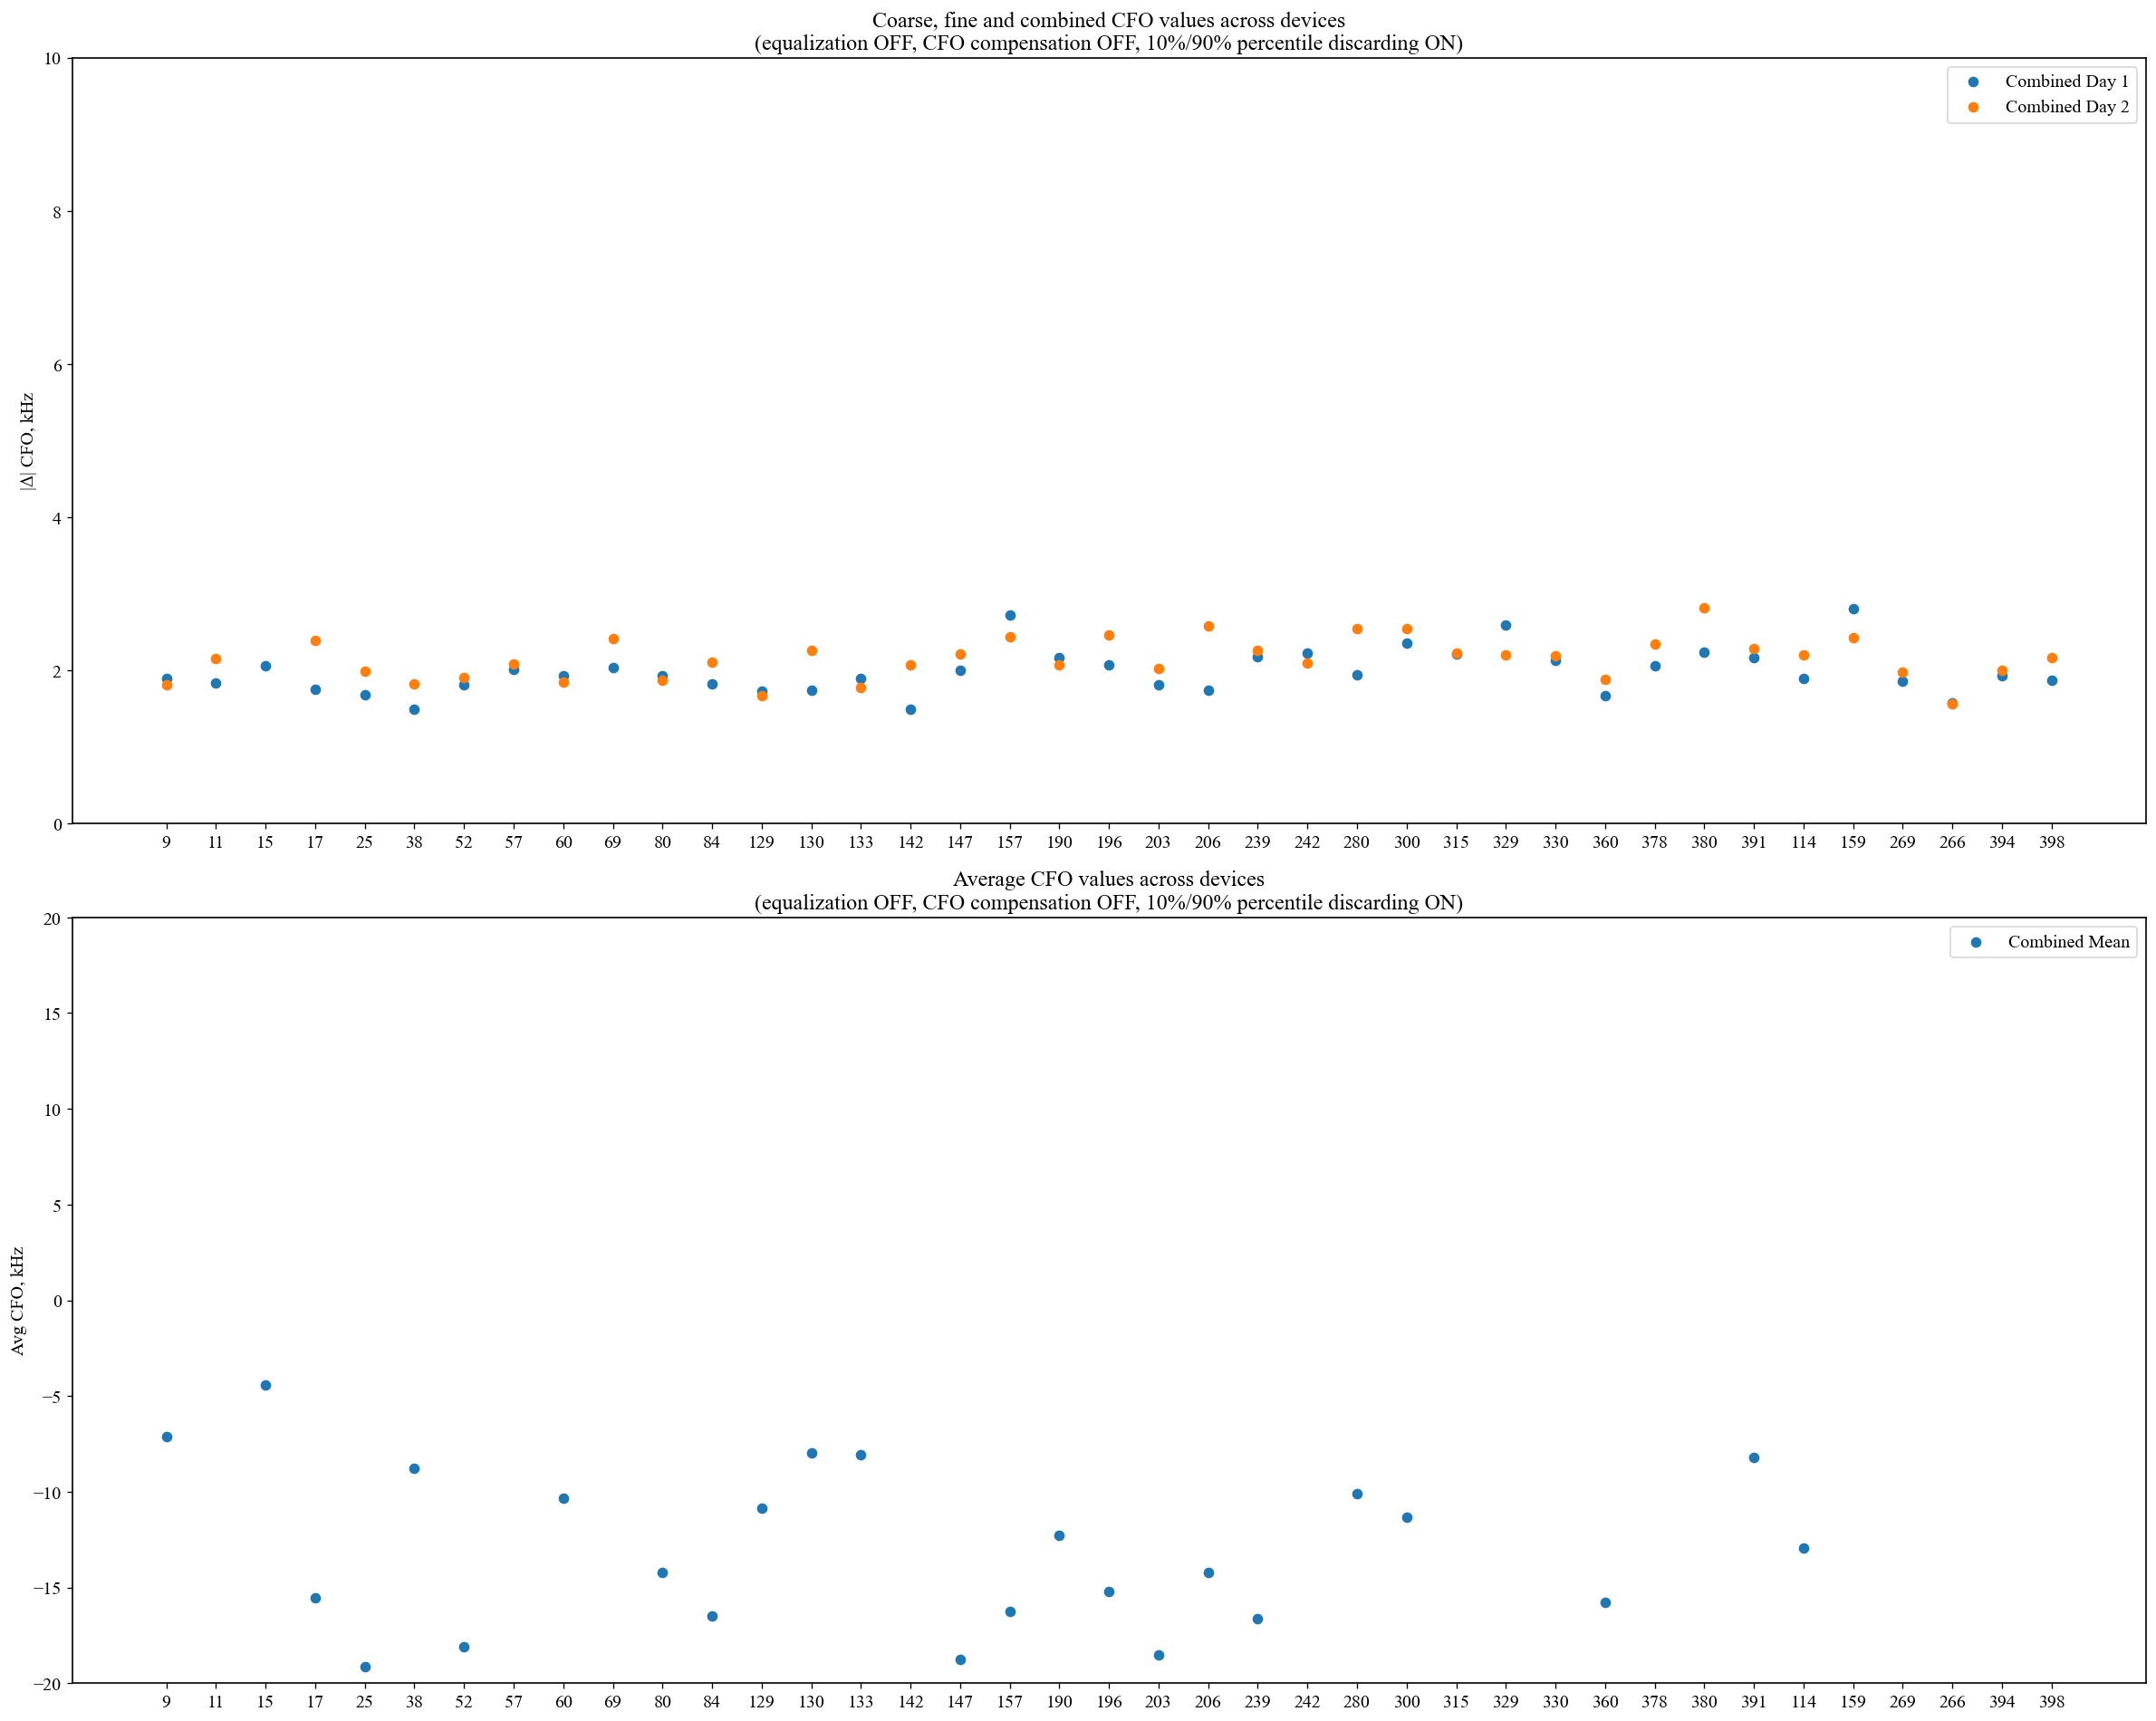

In [111]:

equalization_on = False
cfo_compensation_on = False
cfo_frame_discarding_on = True

route_chunk = 'eq' if equalization_on else 'non_eq'

data_raw_11, label_raw_11, _ = dataset_api.load_raw_dataset_wisig_eq(
    path=f'/home/smazokha2016/Desktop/wisig_dataset_1rx/wisig_dataset-2021_03_01/Train/node1-1_{route_chunk}_train.h5', 
    shuffle=False, compensate_cfo=cfo_compensation_on)
data_raw_12, label_raw_12, _ = dataset_api.load_raw_dataset_wisig_eq(
    path=f'/home/smazokha2016/Desktop/wisig_dataset_1rx/wisig_dataset-2021_03_01/Test/{route_chunk}_epoch_2021-03-01_00-00-00.h5', 
    shuffle=False, compensate_cfo=cfo_compensation_on)
data_raw_21, label_raw_21, _ = dataset_api.load_raw_dataset_wisig_eq(
    path=f'/home/smazokha2016/Desktop/wisig_dataset_1rx/wisig_dataset-2021_03_08/Train/node1-1_{route_chunk}_train.h5', 
    shuffle=False, compensate_cfo=cfo_compensation_on)
data_raw_22, label_raw_22, _ = dataset_api.load_raw_dataset_wisig_eq(
    path=f'/home/smazokha2016/Desktop/wisig_dataset_1rx/wisig_dataset-2021_03_08/Test/{route_chunk}_epoch_2021-03-08_00-00-00.h5', 
    shuffle=False, compensate_cfo=cfo_compensation_on)

data_raw_1, label_raw_1 = combine_datasets(datas=[data_raw_11, data_raw_12], labels=[label_raw_11, label_raw_12])
data_raw_2, label_raw_2 = combine_datasets(datas=[data_raw_21, data_raw_22], labels=[label_raw_21, label_raw_22])

# Training devices
# Note: these are not all devices available in WiSig. This is a union between devices available on Day 1 and Day 2.
train_device_ids = [9, 11, 15, 17, 25, 38, 52, 57, 60, 69, 80, 84, 129, 130, 133, 142, 147, 157, 190, 196, 203, 206, 239, 242, 280, 300, 315, 329, 330, 360, 378, 380, 391]
# Testing devices: disjoint set
test_device_ids_disjoint = [114, 159, 269, 266, 394, 398]
# Testing devices: joint set (subset of training)
test_device_ids_joint = [9, 11, 15, 17, 25, 38]
# Combined joint and disjoint
combined_device_ids = train_device_ids + test_device_ids_disjoint

device_ids = combined_device_ids

coarse_day1_deltas = []
coarse_day2_deltas = []
coarse_means = []
fine_day1_deltas = []
fine_day2_deltas = []
fine_means = []
combined_day1_deltas = []
combined_day2_deltas = []
combined_means = []
combined_maxes = []
combined_mins = []

# plt.figure(figsize=(10, 8), dpi=80)
for device_id in device_ids:
    data_raw_1_dev, label_raw_1_dev, _ = dataset_api.filter_dataset(data_raw_1, label_raw_1, None, dev_range=[device_id], pkt_range=np.arange(0, 500))
    data_raw_2_dev, label_raw_2_dev, _ = dataset_api.filter_dataset(data_raw_2, label_raw_2, None, dev_range=[device_id], pkt_range=np.arange(0, 500))

    if cfo_frame_discarding_on:
        data_raw_1_dev, _, _ = dataset_api.filter_frames_by_cfo(data_raw_1_dev, label_raw_1_dev, None, show=False)
        data_raw_2_dev, _, _ = dataset_api.filter_frames_by_cfo(data_raw_2_dev, label_raw_2_dev, None, show=False)

    # Estimate coarse and fine CFO, and convert to kHz (divide by 1000)
    cfo_1 = cfo_utils.extract_data_cfo(data_raw_1_dev) / 1000
    cfo_2 = cfo_utils.extract_data_cfo(data_raw_2_dev) / 1000
    cfo_comb = np.vstack((cfo_1, cfo_2))
    
    # plt.plot(range(0, cfo_comb.shape[0]), cfo_comb[:, 0], label=f"Coarse. Device ID: {device_id}")
    # plt.plot(range(0, cfo_comb.shape[0]), cfo_comb[:, 1], label=f"Fine. Device ID: {device_id}")
    # plt.plot(range(0, cfo_comb.shape[0]), cfo_comb[:, 0] + cfo_comb[:, 1], label=f"Combined. Device ID: {device_id}")

    coarse_day1_min = min(cfo_1[:, 0])
    coarse_day1_max = max(cfo_1[:, 0])
    coarse_day1_delta = abs(coarse_day1_max - coarse_day1_min)
    coarse_day2_min = min(cfo_2[:, 0])
    coarse_day2_max = max(cfo_2[:, 0])
    coarse_day2_delta = abs(coarse_day2_max - coarse_day2_min)
    coarse_mean = np.mean(cfo_comb[:, 0])

    fine_day1_min = min(cfo_1[:, 1])
    fine_day1_max = max(cfo_1[:, 1])
    fine_day1_delta = abs(fine_day1_max - fine_day1_min)
    fine_day2_min = min(cfo_2[:, 1])
    fine_day2_max = max(cfo_2[:, 1])
    fine_day2_delta = abs(fine_day2_max - fine_day2_min)
    fine_mean = np.mean(cfo_comb[:, 1])

    combined_day1_min = min(cfo_1[:, 0] + cfo_1[:, 1])
    combined_day1_max = max(cfo_1[:, 0] + cfo_1[:, 1])
    combined_day1_delta = abs(combined_day1_max - combined_day1_min)
    combined_day2_min = min(cfo_2[:, 0] + cfo_2[:, 1])
    combined_day2_max = max(cfo_2[:, 0] + cfo_2[:, 1])
    combined_day2_delta = abs(combined_day2_max - combined_day2_min)
    combined_mean = np.mean(cfo_comb[:, 0] + cfo_comb[:, 1])

    coarse_day1_deltas.append(coarse_day1_delta)
    coarse_day2_deltas.append(coarse_day2_delta)
    coarse_means.append(coarse_mean)
    fine_day1_deltas.append(fine_day1_delta)
    fine_day2_deltas.append(fine_day2_delta)
    fine_means.append(fine_mean)
    combined_day1_deltas.append(combined_day1_delta)
    combined_day2_deltas.append(combined_day2_delta)
    combined_means.append(combined_mean)
    combined_maxes.append(max(combined_day1_max, combined_day2_max))
    combined_mins.append(min(combined_day1_min, combined_day2_min))
    
    # print(f'Device #{device_id}. Coarse CFO:')
    # print(f'- Day 1. min: {round(coarse_day1_min, 2)} kHz. max: {round(coarse_day1_max, 2)} kHz. Δ: {round(coarse_day1_delta, 2)} kHz')
    # print(f'- Day 2. min: {round(coarse_day2_min, 2)} kHz. max: {round(coarse_day2_max, 2)} kHz. Δ: {round(coarse_day2_delta, 2)} kHz')
    # print(f'Device #{device_id}. Fine CFO:')
    # print(f'- Day 1. min: {round(fine_day1_min, 2)} kHz. max: {round(fine_day1_max, 2)} kHz. Δ: {round(fine_day1_delta, 2)} kHz')
    # print(f'- Day 2. min: {round(fine_day2_min, 2)} kHz. max: {round(fine_day2_max, 2)} kHz. Δ: {round(fine_day2_delta, 2)} kHz')
    # print(f'Device #{device_id}. Combined CFO:')
    # print(f'- Day 1. min: {round(combined_day1_min, 2)} kHz. max: {round(combined_day1_max, 2)} kHz. Δ: {round(combined_day1_delta, 2)} kHz')
    # print(f'- Day 2. min: {round(combined_day2_min, 2)} kHz. max: {round(combined_day2_max, 2)} kHz. Δ: {round(combined_day2_delta, 2)} kHz')
    # print('===================================================================')

# plt.legend()
# plt.ylim(-20, 20)
# plt.xlabel('Sample Index. Day 1: 400-499. Day 2: 400-499.')
# plt.ylabel('Absolute CFO Values, kHz')
# plt.show()

device_count = len(device_ids)
title_equalization = "ON" if equalization_on else "OFF"
title_cfo_compensation = "ON" if cfo_compensation_on else "OFF"
title_cfo_filtering = "ON" if cfo_frame_discarding_on else "OFF"

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 16), dpi=120)

# First subplot (deltas)
# ax1.scatter(range(device_count), coarse_day1_deltas, label='Coarse Day 1')
# ax1.scatter(range(device_count), coarse_day2_deltas, label='Coarse Day 2')
# ax1.scatter(range(device_count), fine_day1_deltas, label='Fine Day 1')
# ax1.scatter(range(device_count), fine_day2_deltas, label='Fine Day 2')
ax1.scatter(range(device_count), combined_day1_deltas, label='Combined Day 1')
ax1.scatter(range(device_count), combined_day2_deltas, label='Combined Day 2')
ax1.set_xticks(range(device_count))
ax1.set_xticklabels(device_ids)
ax1.legend()
ax1.set_ylabel('|Δ| CFO, kHz')
ax1.set_ylim(0, 10)
ax1.set_title(f'Coarse, fine and combined CFO values across devices\n(equalization {title_equalization}, CFO compensation {title_cfo_compensation}, 10%/90% percentile discarding {title_cfo_filtering})')

# Second subplot (means)
# ax2.scatter(range(device_count), coarse_means, label='Coarse Mean')
# ax2.scatter(range(device_count), fine_means, label='Fine Mean')
ax2.scatter(range(device_count), combined_means, label='Combined Mean')
ax2.set_xticks(range(device_count))
ax2.set_xticklabels(device_ids)
ax2.legend()
ax2.set_ylabel('Avg CFO, kHz')
ax2.set_ylim(-20, 20)
ax2.set_title(f'Average CFO values across devices\n(equalization {title_equalization}, CFO compensation {title_cfo_compensation}, 10%/90% percentile discarding {title_cfo_filtering})')

# Adjust the spacing between subplots
plt.tight_layout()
plt.show()

In [154]:
data_raw_11, label_raw_11, _ = dataset_api.load_raw_dataset_wisig_eq(
    path=f'/home/smazokha2016/Desktop/wisig_dataset_1rx/wisig_dataset-2021_03_01/Train/node1-1_{route_chunk}_train.h5', 
    shuffle=False, compensate_cfo=False, augment_cfo=True)

Not removing CFO.
Augmenting the dataset: x5, CFO range: [-14, -2.5], dist: gaussian
